<a href="https://colab.research.google.com/github/nonyeezeh/MAS-Research-Code/blob/main/Education.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Mean:  6.04 
Std:  1.98 
Low Thresh:  4.06 
High Thresh:  8.01


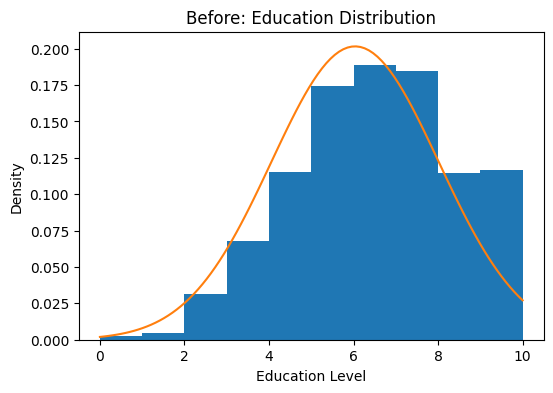

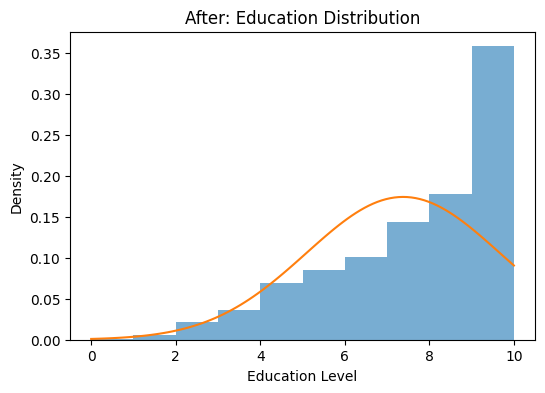


--- TRANSITION MATRIX (%) ---

from \ to   low     mid     high
low         94.2%    5.8%    0.0%
mid          0.3%   94.9%    4.8%
high         0.0%    2.3%   97.7%


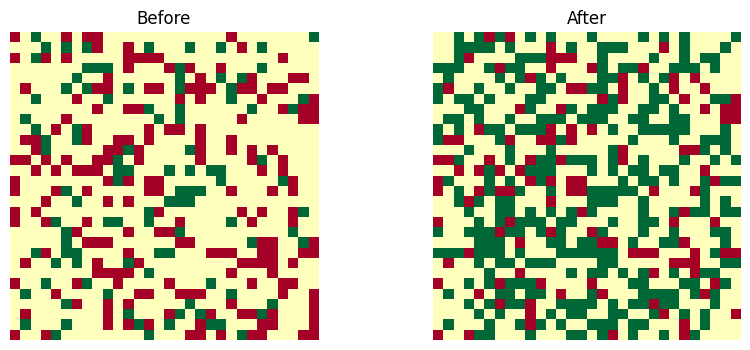

In [ ]:
# -----------------------
# INITIAL EDUCATION
# -----------------------
size = 30

education = np.random.normal(6, 2, (size, size)) # assigning education levels randomly using a normal distribution: Mean = 6 → average education level; Std = 2 → how spread out people are
education = np.clip(education, 0, 10) # 0 ≤ education ≤ 10
education = np.rint(education).astype(int) # convert everything into whole numbers by rounding to nearest int

def compute_thresholds(edu): # Agents below mean - std are “low education” group. Agents above mean + std are “high education” group. Everyone in between is “average education.”
    mean = np.mean(edu)
    std = np.std(edu)
    return mean - std, mean + std

lower_threshold, upper_threshold = compute_thresholds(education)

print("Mean: ", round(np.mean(education),2), # display
      "\nStd: ", round(np.std(education),2),
      "\nLow Thresh: ", round(lower_threshold,2),
      "\nHigh Thresh: ", round(upper_threshold,2))

"""
low, high = np.percentile(education, [25, 75])

print("Mean/Std thresholds:", round(lower_threshold,2), round(upper_threshold,2))
print("Percentile thresholds:", low, high)
"""

# -----------------------
# HISTOGRAM (BEFORE)
# -----------------------
plt.figure(figsize=(6,4)) # figure size

values = education.flatten() # Converts your 30×30 matrix into a 1D array of 900 values. This makes it easier to plot a histogram.
plt.hist(values, bins=10, density=True, alpha=1) # This shows how many agents fall into each education level. | bins=10 → splits the range (1–10) into 10 buckets | density=True → normalizes the histogram so the area under it equals 1 (probability density) | alpha=0.6 → makes the bars semi-transparent.

x = np.linspace(min(values), max(values), 100) # x → 100 evenly spaced points between min and max education values.
y = (1/(np.std(values)*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-np.mean(values))/np.std(values))**2) # y → the Gaussian probability density function (PDF), using your data’s mean and std. This curve shows the theoretical “bell shape” that our histogram should roughly follow.

plt.plot(x, y)

plt.title("Before: Education Distribution")
plt.xlabel("Education Level")
plt.ylabel("Density")
plt.show() # Displays the histogram with the Gaussian curve overlay.

# -----------------------
# CLASS FUNCTION
# -----------------------
def get_classes():
    classes = np.zeros((size,size)) # Creates a 30×30 matrix filled with zeros. This will store the “class” category for each agent.

    classes[education < lower_threshold] = 0 # Assign classes based on thresholds
    classes[(education >= lower_threshold) & (education < upper_threshold)] = 1
    classes[education >= upper_threshold] = 2

    return classes # The function returns the classes matrix, which mirrors the shape of education but contains categorical labels (0, 1, 2) instead of raw education levels.

# -----------------------
# STEP FUNCTION
# -----------------------
def step():
    global education # Ensures the function modifies the main education matrix directly.

    classes = get_classes() # Uses your earlier function to classify each agent into low (0), middle (1), or high (2) class.

    mean = np.mean(education) # Calculates the overall mean and standard deviation of education.
    std = np.std(education) + 1e-8 # The tiny + 1e-8 prevents division by zero.

    for i in range(size): # Iterates through every agent in your grid.
        for j in range(size):

            agent_class = classes[i,j]

            # UPWARD MOBILITY PROBABILITY
            if agent_class == 0:
                p_up = 0.1
            elif agent_class == 1:
                p_up = 0.2
            else:
                p_up = 0.5 # modeling that higher classes have more opportunity for upward class mobility based on education growth.

            # DOWNWARD MOBILITY PROBABILITY
            z = (education[i,j] - mean) / std # z = how far above the mean this agent is (a z-score).
            alpha = 0.05
            base_down = 0.02 # Base downward chance = 2%.
            p_down = base_down + alpha * max(0, z) # The higher above average an agent is, the more risk of downward mobility (perhaps modeling regression to the mean or societal pressures).


            r = np.random.random() # Draws a random number between 0 and 1.
            if r < p_up:
                education[i,j] += 1 # If it falls in the upward probability range → agent’s education increases by 1.
            elif r < p_up + p_down:
                education[i,j] -= 1 # If it falls in the downward range → agent’s education decreases by 1. Otherwise → no change.

    education = np.clip(education, 0, 10).astype(int) # Keeps education levels between 0 and 10. Converts back to integers.

# -----------------------
# BEFORE STATE
# -----------------------
classes_before = get_classes() # Captures the initial class distribution before any mobility steps happen. This is your baseline snapshot of society.

# -----------------------
# TRANSITION MATRIX
# -----------------------
transition_matrix = np.zeros((3,3)) # Creates a 3×3 matrix to track movements between classes.

# -----------------------
# RUN SIMULATION
# -----------------------
steps = 10 # Runs the simulation for 10 steps.

for _ in range(steps):

    old_classes = get_classes().copy() # Record old class distribution.

    step() # Apply mobility rules (step()).

    new_classes = get_classes() # Record new class distribution.

    # -----------------------
    # TRANSITION MATRIX UPDATE
    # -----------------------
    for i in range(size):
        for j in range(size):
            transition_matrix[
                int(old_classes[i, j]),
                int(new_classes[i, j])
            ] += 1 # For each agent, increment the matrix cell corresponding to their movement. I.e. if an agent was class 1 and became class 2, increment [1,2]. After all steps, the matrix shows the flow of agents between classes.

# -----------------------
# AFTER STATE
# -----------------------
classes_after = get_classes() # Captures the final class distribution after all mobility steps. Lets us compare “before” vs “after” society.

# -----------------------
# HISTOGRAM (AFTER)
# -----------------------
plt.figure(figsize=(6,4))

values_after = education.flatten()
plt.hist(values_after, bins=10, density=True, alpha=0.6)

x = np.linspace(min(values_after), max(values_after), 100)
y = (1/(np.std(values_after)*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-np.mean(values_after))/np.std(values_after))**2)

plt.plot(x, y)

plt.title("After: Education Distribution")
plt.xlabel("Education Level")
plt.ylabel("Density")
plt.show()

# -----------------------
# TRANSITION PERCENTAGES
# -----------------------
transition_percent = transition_matrix / (transition_matrix.sum(axis=1, keepdims=True) + 1e-8) # transition probabilities (Markov chain)

labels = ["low", "mid", "high"] # Percentage of how many agents moved from one class to another.

print("\n--- TRANSITION MATRIX (%) ---\n")
print("from \\ to   low     mid     high")

for i in range(3):
    row = transition_percent[i]
    print(
        f"{labels[i]:<5}      "
        f"{row[0]*100:5.1f}%  "
        f"{row[1]*100:5.1f}%  "
        f"{row[2]*100:5.1f}%"
    )

# -----------------------
# GRID COMPARISON
# -----------------------
fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].imshow(classes_before, cmap="RdYlGn", vmin=0, vmax=2)
ax[0].set_title("Before")
ax[0].axis("off")

ax[1].imshow(classes_after, cmap="RdYlGn", vmin=0, vmax=2)
ax[1].set_title("After")
ax[1].axis("off")

plt.show()